In [1]:
# ── Cell 1: Environment fix + imports ──────────────────────────────────────
import subprocess, sys

# Now import everything
import os, time, math, json, warnings, itertools
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import defaultdict
from PIL import Image
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

# Verify
print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.version.cuda}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device   : {device}")
if torch.cuda.is_available():
    print(f"GPU      : {torch.cuda.get_device_name(0)}")

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.benchmark = True

# Quick GPU test
_t = torch.randn(2, 3, 32, 32).to(device)
print(f"GPU tensor test : {_t.shape} ✔")
del _t

PyTorch  : 2.10.0+cu128
CUDA     : 12.8
Device   : cuda
GPU      : Tesla T4
GPU tensor test : torch.Size([2, 3, 32, 32]) ✔


In [2]:
import os, zipfile, pandas as pd
from PIL import Image

BASE = "/kaggle/input/datasets/wordroid/cifar10-object-recognition-in-images-zip-file"
WORK = "/kaggle/working"

# ── Extract train.zip ─────────────────────────────────────────────────────────
train_zip = os.path.join(BASE, "train_test", "train.zip")
train_dir = os.path.join(WORK, "train")

if not os.path.exists(train_dir):
    print("Extracting train.zip ...")
    with zipfile.ZipFile(train_zip, 'r') as z:
        z.extractall(WORK)
    print("Done.")
else:
    print("Already extracted.")

# ── Load labels CSV ───────────────────────────────────────────────────────────
labels_df = pd.read_csv(os.path.join(BASE, "trainLabels.csv"))
print(f"\nLabels CSV shape : {labels_df.shape}")
print(labels_df.head(8))
print(f"\nUnique classes   : {sorted(labels_df['label'].unique())}")
print(f"Total images     : {len(labels_df)}")

# ── Verify image files exist after extraction ─────────────────────────────────
print(f"\nFiles in {train_dir}:")
sample_files = os.listdir(train_dir)[:5]
print(sample_files)

sample_id = labels_df['id'].iloc[0]
for ext in [".png", ".jpg"]:
    path = os.path.join(train_dir, str(sample_id) + ext)
    if os.path.exists(path):
        img = Image.open(path)
        print(f"\nSample image : {sample_id}{ext}  |  Size: {img.size}  |  Mode: {img.mode}")
        break

Extracting train.zip ...
Done.

Labels CSV shape : (50000, 2)
   id       label
0   1        frog
1   2       truck
2   3       truck
3   4        deer
4   5  automobile
5   6  automobile
6   7        bird
7   8       horse

Unique classes   : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Total images     : 50000

Files in /kaggle/working/train:
['23357.png', '12841.png', '44085.png', '47506.png', '8367.png']

Sample image : 1.png  |  Size: (32, 32)  |  Mode: RGB


Classes : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Mapping : {'airplane': 0, 'automobile': 1, 'bird': 2, 'cat': 3, 'deer': 4, 'dog': 5, 'frog': 6, 'horse': 7, 'ship': 8, 'truck': 9}
Image extension : .png

Train split : 40000 images
Val split   : 10000 images

Computed mean : [0.4914, 0.4824, 0.4468]
Computed std  : [0.2469, 0.2435, 0.2616]


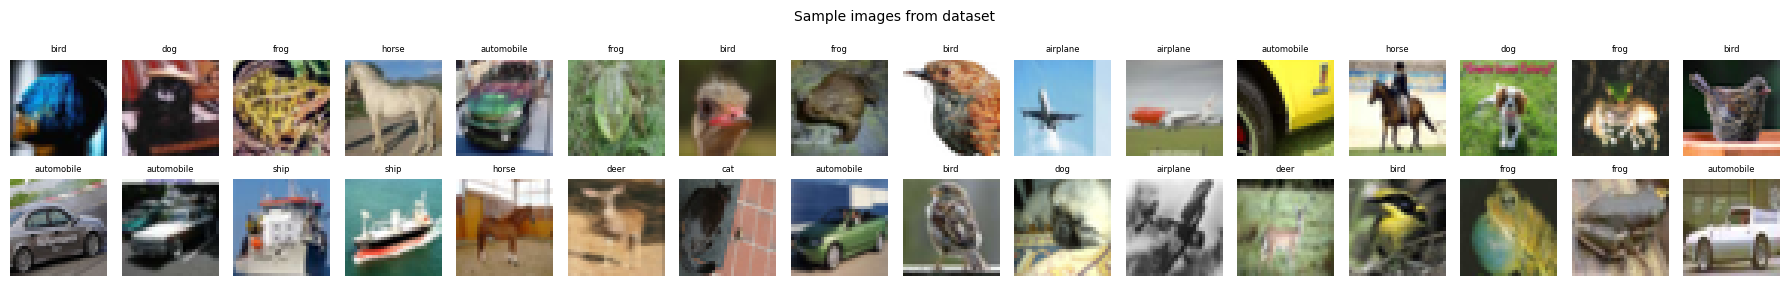

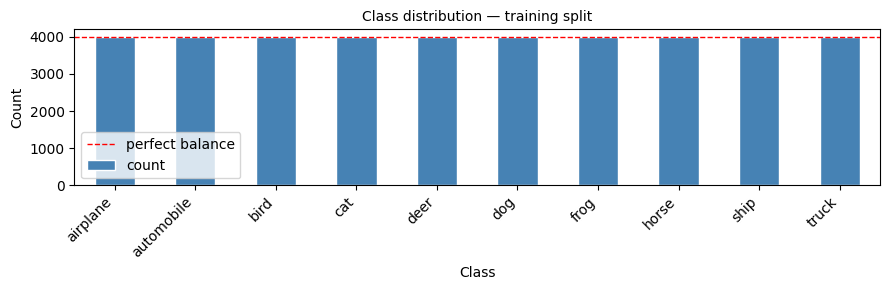

In [3]:
from torch.utils.data import Dataset
from torchvision import transforms
import torch

# ── Build label map ───────────────────────────────────────────────────────────
CLASSES   = sorted(labels_df['label'].unique())
CLASS2IDX = {c: i for i, c in enumerate(CLASSES)}
print(f"Classes : {CLASSES}")
print(f"Mapping : {CLASS2IDX}")

# ── Figure out image extension ────────────────────────────────────────────────
_sample = str(labels_df['id'].iloc[0])
EXT = ".png" if os.path.exists(os.path.join(train_dir, _sample + ".png")) else ".jpg"
print(f"Image extension : {EXT}")


# ── Train / val split ─────────────────────────────────────────────────────────
# CIFAR-10 standard: 50k train, 10k val
# The Kaggle dataset has 50k labelled images — we carve out 10k as our test set
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    labels_df, test_size=0.2, stratify=labels_df['label'], random_state=SEED
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
print(f"\nTrain split : {len(train_df)} images")
print(f"Val split   : {len(val_df)} images")


# ── Custom Dataset ────────────────────────────────────────────────────────────

class CIFAR10Dataset(Dataset):
    """
    Loads CIFAR-10 images from the Kaggle flat-folder format.
    Images are named by integer id (e.g. 1.png, 2.png ...).
    Labels come from trainLabels.csv.
    """
    def __init__(self, df, img_dir, transform=None):
        self.df        = df
        self.img_dir   = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        path  = os.path.join(self.img_dir, str(row['id']) + EXT)
        img   = Image.open(path).convert("RGB")
        label = CLASS2IDX[row['label']]
        if self.transform:
            img = self.transform(img)
        return img, label


# ── Compute dataset mean/std from training split ──────────────────────────────
# Always use dataset-specific stats — not ImageNet values
_raw_ds     = CIFAR10Dataset(train_df, train_dir, transforms.ToTensor())
_raw_loader = DataLoader(_raw_ds, batch_size=512, num_workers=2)

mean = torch.zeros(3)
std  = torch.zeros(3)
for imgs, _ in _raw_loader:
    for c in range(3):
        mean[c] += imgs[:, c].mean()
        std[c]  += imgs[:, c].std()
mean /= len(_raw_loader)
std  /= len(_raw_loader)

CIFAR_MEAN = tuple(mean.tolist())
CIFAR_STD  = tuple(std.tolist())
print(f"\nComputed mean : {[round(x,4) for x in CIFAR_MEAN]}")
print(f"Computed std  : {[round(x,4) for x in CIFAR_STD]}")


# ── Visualise a sample batch ──────────────────────────────────────────────────
_vis_ds     = CIFAR10Dataset(train_df, train_dir, transforms.ToTensor())
_vis_loader = DataLoader(_vis_ds, batch_size=32, shuffle=True)
imgs, lbls  = next(iter(_vis_loader))

_m = torch.tensor(CIFAR_MEAN).view(3,1,1)
_s = torch.tensor(CIFAR_STD).view(3,1,1)

fig, axes = plt.subplots(2, 16, figsize=(18, 3))
for i in range(16):
    axes[0, i].imshow(imgs[i].permute(1,2,0).clamp(0,1))
    axes[0, i].set_title(CLASSES[lbls[i]], fontsize=6)
    axes[0, i].axis("off")
    axes[1, i].imshow(imgs[i+16].permute(1,2,0).clamp(0,1))
    axes[1, i].set_title(CLASSES[lbls[i+16]], fontsize=6)
    axes[1, i].axis("off")
fig.suptitle("Sample images from dataset", fontsize=10)
plt.tight_layout(); plt.show()

# ── Class distribution check ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 3))
train_df['label'].value_counts().sort_index().plot(kind='bar', ax=ax,
    color='steelblue', edgecolor='white')
ax.set_title("Class distribution — training split", fontsize=10)
ax.set_xlabel("Class"); ax.set_ylabel("Count")
ax.axhline(len(train_df)/10, color='red', ls='--', lw=1, label='perfect balance')
ax.legend(); plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

Train batches : 313
Val   batches : 40


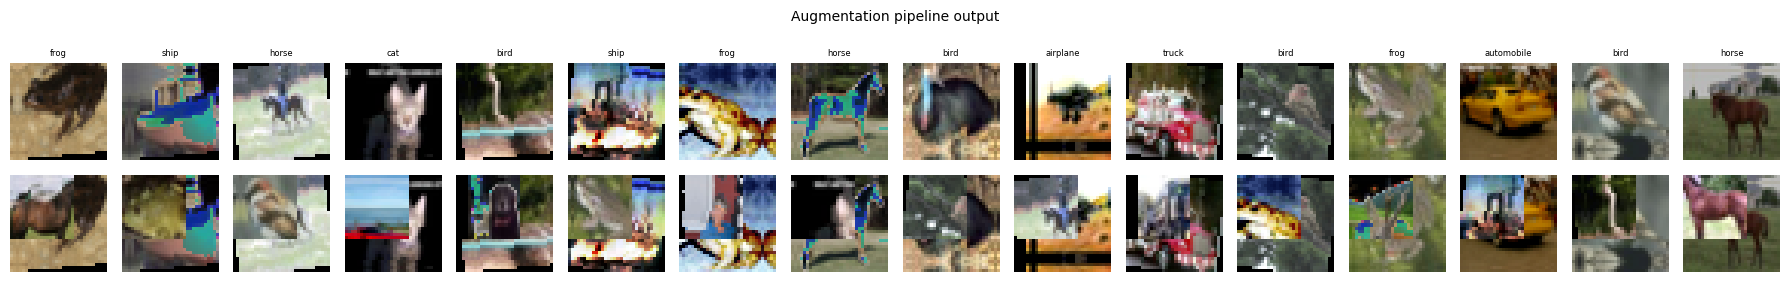

In [4]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4, padding_mode="reflect"),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandAugment(num_ops=2, magnitude=9),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])


def cutmix_batch(images, labels, alpha=1.0):
    """
    Apply CutMix to a batch.
    Cuts a patch from image B and pastes onto image A.
    Labels are mixed proportionally to area: λ·CE(pred, A) + (1-λ)·CE(pred, B)
    Applied in the training loop on batches — NOT in transforms.Compose.
    """
    lam  = np.random.beta(alpha, alpha)
    B, C, H, W = images.shape
    perm = torch.randperm(B, device=images.device)

    cut_ratio = math.sqrt(1.0 - lam)
    cut_h = int(H * cut_ratio)
    cut_w = int(W * cut_ratio)
    cx = np.random.randint(W)
    cy = np.random.randint(H)
    x1 = max(cx - cut_w // 2, 0); x2 = min(cx + cut_w // 2, W)
    y1 = max(cy - cut_h // 2, 0); y2 = min(cy + cut_h // 2, H)

    images_mixed = images.clone()
    images_mixed[:, :, y1:y2, x1:x2] = images[perm, :, y1:y2, x1:x2]
    lam = 1 - (x2 - x1) * (y2 - y1) / (W * H)
    return images_mixed, labels, labels[perm], lam


# ── Build datasets and loaders ────────────────────────────────────────────────
train_dataset = CIFAR10Dataset(train_df, train_dir, transform=train_transform)
val_dataset   = CIFAR10Dataset(val_df,   train_dir, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True,
                          num_workers=0,
                          pin_memory=True)

test_loader  = DataLoader(val_dataset, batch_size=256, shuffle=False,
                          num_workers=0,
                          pin_memory=True)

print(f"Train batches : {len(train_loader)}")
print(f"Val   batches : {len(test_loader)}")

# ── Visualise augmentation ────────────────────────────────────────────────────
_vis_ds     = CIFAR10Dataset(train_df, train_dir, transform=train_transform)
_vis_loader = DataLoader(_vis_ds, batch_size=32, shuffle=True)
imgs, lbls  = next(iter(_vis_loader))

_m = torch.tensor(CIFAR_MEAN).view(3,1,1)
_s = torch.tensor(CIFAR_STD).view(3,1,1)

imgs_cut, la, lb, lam = cutmix_batch(imgs, lbls)
imgs_disp     = (imgs     * _s + _m).clamp(0, 1)
imgs_cut_disp = (imgs_cut * _s + _m).clamp(0, 1)

fig, axes = plt.subplots(2, 16, figsize=(18, 3))
for i in range(16):
    axes[0, i].imshow(imgs_disp[i].permute(1,2,0))
    axes[0, i].set_title(CLASSES[lbls[i]], fontsize=6)
    axes[0, i].axis("off")
    axes[1, i].imshow(imgs_cut_disp[i].permute(1,2,0))
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("RandAugment", fontsize=8)
axes[1, 0].set_ylabel(f"+ CutMix\n(λ={lam:.2f})", fontsize=8)
fig.suptitle("Augmentation pipeline output", fontsize=10)
plt.tight_layout(); plt.show()

In [5]:
class PrunableLinear(nn.Module):
    """
    Sigmoid-gated linear layer.

    gate_{ij} = σ(gate_scores_{ij})
    effective_weight = weight ⊙ gate
    output = x @ effective_weight.T + bias

    L1(gates) as sparsity loss — constant gradient pressure drives gates to 0.
    Limitation: σ(s) → 0 asymptotically, never exactly 0.
    """
    def __init__(self, in_features, out_features, name=""):
        super().__init__()
        self.in_features  = in_features
        self.out_features = out_features
        self.name         = name

        self.weight      = nn.Parameter(torch.empty(out_features, in_features))
        self.bias        = nn.Parameter(torch.zeros(out_features))
        self.gate_scores = nn.Parameter(torch.zeros(out_features, in_features))

        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        fan_in, _ = nn.init._calculate_fan_in_and_fan_out(self.weight)
        nn.init.uniform_(self.bias, -1/math.sqrt(fan_in), 1/math.sqrt(fan_in))

    def forward(self, x):
        gates         = torch.sigmoid(self.gate_scores)
        pruned_weight = self.weight * gates
        return F.linear(x, pruned_weight, self.bias)

    def sparsity_loss(self):
        """L1 norm of gate values — sum encourages mass at exactly 0."""
        return torch.sigmoid(self.gate_scores).sum()

    def get_gates(self):
        return torch.sigmoid(self.gate_scores).detach().cpu()

    def layer_sparsity(self, thresh=1e-2):
        return float((self.get_gates().numpy() < thresh).mean()) * 100

    def gate_entropy(self):
        """
        Mean binary entropy H = -p·log2(p) - (1-p)·log2(1-p).
        H→1: gate undecided (near 0.5)
        H→0: gate committed (near 0 or 1)
        Tracks when the network decides what to prune.
        """
        g = self.get_gates().numpy().ravel().clip(1e-7, 1-1e-7)
        return float((-g*np.log2(g) - (1-g)*np.log2(1-g)).mean())


class HardConcretePrunableLinear(nn.Module):
    """
    Hard Concrete gates (Louizos et al. 2018).
    Fixes sigmoid's asymptotic-zero limitation — gives P(gate=0) > 0.
    Regularisation becomes true expected-L0 norm, not an L1 proxy.
    Drop-in replacement for PrunableLinear.
    """
    LO, HI, BETA = -0.1, 1.1, 2/3

    def __init__(self, in_features, out_features, name=""):
        super().__init__()
        self.in_features  = in_features
        self.out_features = out_features
        self.name         = name

        self.weight    = nn.Parameter(torch.empty(out_features, in_features))
        self.bias      = nn.Parameter(torch.zeros(out_features))
        self.log_alpha = nn.Parameter(torch.zeros(out_features, in_features))

        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        fan_in, _ = nn.init._calculate_fan_in_and_fan_out(self.weight)
        nn.init.uniform_(self.bias, -1/math.sqrt(fan_in), 1/math.sqrt(fan_in))

    def _gates(self):
        if self.training:
            u = torch.zeros_like(self.log_alpha).uniform_().clamp(1e-8, 1-1e-8)
            s = torch.sigmoid(
                (u.log() - (1-u).log() + self.log_alpha) / self.BETA
            )
        else:
            s = torch.sigmoid(self.log_alpha)
        return (s * (self.HI - self.LO) + self.LO).clamp(0, 1)

    def forward(self, x):
        return F.linear(x, self.weight * self._gates(), self.bias)

    def sparsity_loss(self):
        return torch.sigmoid(
            self.log_alpha - self.BETA * math.log(-self.LO / self.HI)
        ).sum()

    def get_gates(self):
        with torch.no_grad():
            s = torch.sigmoid(self.log_alpha)
            return (s * (self.HI - self.LO) + self.LO).clamp(0, 1).cpu()

    def layer_sparsity(self, thresh=1e-2):
        return float((self.get_gates().numpy() < thresh).mean()) * 100

    def gate_entropy(self):
        g = self.get_gates().numpy().ravel().clip(1e-7, 1-1e-7)
        return float((-g*np.log2(g) - (1-g)*np.log2(1-g)).mean())


class SEBlock(nn.Module):
    """
    Squeeze-and-Excitation block (Hu et al. 2018).
    Learns which channels matter for the current input.
    Global avg pool → FC(C/r) → ReLU → FC(C) → Sigmoid → rescale.
    r=16 gives best accuracy/parameter trade-off per original paper.
    """
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return x * self.se(x).view(x.size(0), x.size(1), 1, 1)


class ResBlock(nn.Module):
    """
    Pre-activation ResBlock (He et al. 2016 v2: BN→ReLU→Conv).
    Pre-activation improves gradient flow vs original post-activation.
    """
    def __init__(self, in_c, out_c, stride=1, use_se=False):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.BatchNorm2d(in_c), nn.ReLU(inplace=True),
            nn.Conv2d(in_c, out_c, 3, stride=stride, padding=1, bias=False)
        )
        self.conv2 = nn.Sequential(
            nn.BatchNorm2d(out_c), nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1, bias=False)
        )
        self.se       = SEBlock(out_c) if use_se else nn.Identity()
        self.shortcut = nn.Identity()
        if stride != 1 or in_c != out_c:
            self.shortcut = nn.Sequential(
                nn.BatchNorm2d(in_c),
                nn.Conv2d(in_c, out_c, 1, stride=stride, bias=False)
            )

    def forward(self, x):
        return self.se(self.conv2(self.conv1(x))) + self.shortcut(x)


class SEResNetPrunable(nn.Module):
    """
    SE-ResNet-56 backbone + PrunableLinear classifier head.

    Design decisions:
    - No MaxPool after stem: 32×32 is too small, early pooling destroys info
    - SE attention on Stage 4 only: recalibrates task-specific features
      before the prunable head makes classification decisions
    - Prunable head only: conv layers learn shared representations,
      pruning targets the task-specific dense layers
    """
    def __init__(self, num_classes=10, gate_type="sigmoid"):
        super().__init__()
        Layer = (PrunableLinear if gate_type == "sigmoid"
                 else HardConcretePrunableLinear)

        # Stem — no pooling
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )

        def make_stage(in_c, out_c, n_blocks, stride=1, use_se=False):
            layers = [ResBlock(in_c, out_c, stride=stride, use_se=use_se)]
            for _ in range(1, n_blocks):
                layers.append(ResBlock(out_c, out_c, use_se=use_se))
            return nn.Sequential(*layers)

        # ResNet-56: 9 blocks per stage
        self.stage1 = make_stage(64,  64,  9, stride=1, use_se=False)
        self.stage2 = make_stage(64,  128, 9, stride=2, use_se=False)
        self.stage3 = make_stage(128, 256, 9, stride=2, use_se=False)
        self.stage4 = make_stage(256, 512, 9, stride=2, use_se=True)

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc1  = Layer(512, 256, name="fc1")
        self.fc2  = Layer(256, num_classes, name="fc2")
        self.drop = nn.Dropout(0.3)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.pool(x).flatten(1)
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        return self.fc2(x)

    def prunable_layers(self):
        return [m for m in self.modules()
                if isinstance(m, (PrunableLinear, HardConcretePrunableLinear))]

    def total_sparsity_loss(self):
        return sum(l.sparsity_loss() for l in self.prunable_layers())

    def get_all_gates(self):
        return np.concatenate(
            [l.get_gates().numpy().ravel() for l in self.prunable_layers()]
        )

    def global_sparsity(self, thresh=1e-2):
        g = self.get_all_gates()
        return float((g < thresh).mean()) * 100

    def layer_sparsity_report(self):
        return {l.name: f"{l.layer_sparsity():.1f}%"
                for l in self.prunable_layers()}

    def layer_entropy_report(self):
        return {l.name: l.gate_entropy()
                for l in self.prunable_layers()}


# Sanity check
_m   = SEResNetPrunable().to(device)
_x   = torch.randn(2, 3, 32, 32).to(device)
_out = _m(_x)
print(f"Forward pass OK — output shape : {_out.shape}")
del _m, _x, _out

Forward pass OK — output shape : torch.Size([2, 10])


In [6]:
def model_summary(model, input_size=(1, 3, 32, 32)):
    total = trainable = 0
    rows  = []
    hooks = []

    def hook(module, inp, out):
        params    = sum(p.numel() for p in module.parameters(recurse=False))
        tp        = sum(p.numel() for p in module.parameters(recurse=False)
                        if p.requires_grad)
        shape     = str(tuple(out.shape)) if torch.is_tensor(out) else "—"
        rows.append((type(module).__name__, shape, params, tp))

    for m in model.modules():
        if len(list(m.children())) == 0:
            hooks.append(m.register_forward_hook(hook))

    with torch.no_grad():
        model(torch.randn(*input_size).to(device))
    for h in hooks: h.remove()

    print(f"\n{'Layer':<35} {'Output shape':<22} {'Params':>10}")
    print("─" * 70)
    seen = set()
    for name, shape, params, tp in rows:
        key = (name, shape, params)
        if key in seen: continue
        seen.add(key)
        total     += params
        trainable += tp
        print(f"  {name:<33} {shape:<22} {params:>10,}")
    print("─" * 70)
    print(f"  {'Total':<55} {total:>10,}")
    print(f"  {'Trainable':<55} {trainable:>10,}")

    # Prunable layer breakdown
    print(f"\n  Prunable layer breakdown:")
    for l in model.prunable_layers():
        w = l.weight.numel()
        g = l.gate_scores.numel() if hasattr(l, 'gate_scores') else l.log_alpha.numel()
        print(f"    {l.name:<8}  weights: {w:>8,}  gate params: {g:>8,}")


model = SEResNetPrunable(gate_type="sigmoid").to(device)
model_summary(model)


Layer                               Output shape               Params
──────────────────────────────────────────────────────────────────────
  Conv2d                            (1, 64, 32, 32)             1,728
  BatchNorm2d                       (1, 64, 32, 32)               128
  ReLU                              (1, 64, 32, 32)                 0
  Conv2d                            (1, 64, 32, 32)            36,864
  Identity                          (1, 64, 32, 32)                 0
  Conv2d                            (1, 128, 16, 16)           73,728
  BatchNorm2d                       (1, 128, 16, 16)              256
  ReLU                              (1, 128, 16, 16)                0
  Conv2d                            (1, 128, 16, 16)          147,456
  Identity                          (1, 128, 16, 16)                0
  Conv2d                            (1, 128, 16, 16)            8,192
  Conv2d                            (1, 256, 8, 8)            294,912
  BatchNorm2d     

In [7]:
def get_optimizer(model):
    gate_params  = [p for n, p in model.named_parameters()
                    if "gate_scores" in n]
    other_params = [p for n, p in model.named_parameters()
                    if "gate_scores" not in n]
    
    # SGD for weights (best for ResNet accuracy)
    # Adam for gates (much better at driving gates to zero)
    optimizer = optim.SGD([
        {"params": other_params, "lr": 0.1, "lr_scale": 1.0},
    ], momentum=0.9, nesterov=True, weight_decay=5e-4)
    
    gate_optimizer = optim.Adam([
        {"params": gate_params, "lr": 1e-2}
    ])
    
    return optimizer, gate_optimizer

In [28]:
from collections import defaultdict
from torch.amp import autocast

EPOCHS        = 30
WARMUP_EPOCHS = 3
LAM_WARMUP    = 5
LAMBDA_VALUES = [0.1, 1.0, 5.0]
CUTMIX_PROB   = 0.5
CKPT_DIR      = "/kaggle/working"


def get_lr(epoch, base_lr, warmup=WARMUP_EPOCHS, total=EPOCHS):
    """Linear warmup then cosine decay."""
    if epoch < warmup:
        return base_lr * (epoch + 1) / warmup
    progress = (epoch - warmup) / (total - warmup)
    return base_lr * 0.5 * (1 + math.cos(math.pi * progress))


def get_lambda(epoch, target_lam, warmup=LAM_WARMUP):
    """
    Linear ramp 0 → target_lam over first `warmup` epochs.
    Without this, sparsity pressure collapses gates before the network
    learns useful features — analogous to KL annealing in VAEs.
    """
    if epoch < warmup:
        return target_lam * (epoch + 1) / warmup
    return target_lam


class LabelSmoothingCE(nn.Module):
    """
    Cross-entropy with label smoothing (Szegedy et al. 2016).
    Prevents overconfident softmax — pairs well with CutMix soft targets.
    smoothing=0.1 is standard for CIFAR.
    """
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing

    def forward(self, logits, targets):
        log_prob = F.log_softmax(logits, dim=-1)
        nll      = F.nll_loss(log_prob, targets, reduction="none")
        smooth   = -log_prob.mean(dim=-1)
        return ((1 - self.smoothing) * nll + self.smoothing * smooth).mean()


criterion = LabelSmoothingCE(smoothing=0.1)
from torch.amp import autocast, GradScaler
scaler = GradScaler()

def train_one_epoch(model, loader, optimizer, gate_optimizer, epoch, target_lam):
    model.train()
    
    ce_sum = 0.0
    sp_sum = 0.0
    correct = 0
    total = 0

    lam_eff = get_lambda(epoch, target_lam)
    lr      = get_lr(epoch, 0.1)

    # Update LR
    for pg in optimizer.param_groups:
        pg["lr"] = lr * pg.get("lr_scale", 1.0)

    ran = False  

    for images, labels in loader:
        ran = True

        images, labels = images.to(device), labels.to(device)

        use_cutmix = np.random.rand() < CUTMIX_PROB
        if use_cutmix:
            images, label_a, label_b, mix_lam = cutmix_batch(images, labels)

        optimizer.zero_grad()
        gate_optimizer.zero_grad()

        with autocast(device_type=device.type):
            logits = model(images)

            if use_cutmix:
                ce = (mix_lam       * criterion(logits, label_a)
                      + (1-mix_lam) * criterion(logits, label_b))
            else:
                ce = criterion(logits, labels)

            sp   = model.total_sparsity_loss()
            loss = ce + lam_eff * sp

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)
        scaler.unscale_(gate_optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)

        scaler.step(optimizer)

        has_grad = any(
            p.grad is not None
            for group in gate_optimizer.param_groups
            for p in group['params']
        )
        if has_grad:
            scaler.step(gate_optimizer)

        scaler.update()

        ce_sum += ce.item()
        sp_sum += sp.item()

        preds = logits.argmax(1)

        if use_cutmix:
            correct += (
                mix_lam * (preds == label_a).sum().item() +
                (1 - mix_lam) * (preds == label_b).sum().item()
            )
            total += labels.size(0)
        else:
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    if not ran or total == 0:
        return 0, 0, 0, lr, lam_eff

    n = len(loader)

    return ce_sum / n, sp_sum / n, 100 * correct / total, lr, lam_eff


@torch.no_grad()
def evaluate(model, loader):
    model.eval()

    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        logits = model(images)
        preds = logits.argmax(1)

        correct += (preds == labels).sum().item()
        total   += labels.size(0)

    if total == 0:
        return 0

    return 100 * correct / total


print("Training config ready.")
print(f"  Epochs        : {EPOCHS}")
print(f"  LR warmup     : {WARMUP_EPOCHS} epochs")
print(f"  λ warmup      : {LAM_WARMUP} epochs")
print(f"  CutMix prob   : {CUTMIX_PROB}")
print(f"  λ values      : {LAMBDA_VALUES}")

Training config ready.
  Epochs        : 30
  LR warmup     : 3 epochs
  λ warmup      : 5 epochs
  CutMix prob   : 0.5
  λ values      : [0.1, 1.0, 5.0]


In [29]:
# Patch the method on the currently running model class
def _normalised_sparsity_loss(self):
    total_gates = sum(
        l.gate_scores.numel() 
        for l in self.prunable_layers()
    )
    raw = sum(l.sparsity_loss() for l in self.prunable_layers())
    return raw / total_gates   # now always in [0, 1]

import types
SEResNetPrunable.total_sparsity_loss = _normalised_sparsity_loss


In [30]:
from torch.amp import autocast, GradScaler
all_results = {}

for target_lam in LAMBDA_VALUES:
    print(f"\n{'='*68}")
    print(f"  Training  λ = {target_lam:.0e}")
    print(f"{'='*68}")

    torch.manual_seed(SEED); np.random.seed(SEED)
    model = SEResNetPrunable(gate_type="sigmoid").to(device)

    gate_params  = [p for n, p in model.named_parameters()
                    if "gate_scores" in n]
    other_params = [p for n, p in model.named_parameters()
                    if "gate_scores" not in n]

    optimizer = optim.SGD([
        {"params": other_params, "lr": 0.1, "lr_scale": 1.0},
        {"params": gate_params,  "lr": 0.1, "lr_scale": 0.5},
    ], momentum=0.9, nesterov=True, weight_decay=5e-4)

    history  = defaultdict(list)
    best_acc = 0.0
    t0       = time.time()
    

    scaler = GradScaler()

    for epoch in range(EPOCHS):
        ce, sp, tr_acc, lr, lam_eff = train_one_epoch(
            model, train_loader, optimizer, gate_optimizer, epoch, target_lam
        )
        te_acc    = evaluate(model, test_loader)
        sparsity  = model.global_sparsity()
        entropies = model.layer_entropy_report()

        history["ce"].append(ce)
        history["sparsity"].append(sparsity)
        history["te_acc"].append(te_acc)
        history["lam"].append(lam_eff)
        for k, v in entropies.items():
            history[f"ent_{k}"].append(v)

        if te_acc > best_acc:
            best_acc = te_acc
            torch.save(model.state_dict(),
                       f"{CKPT_DIR}/best_lam{target_lam:.0e}.pt")

        if True:
            elapsed = (time.time() - t0) / 60
            print(f"  Ep {epoch:>3}/{EPOCHS} | "
                  f"lr={lr:.4f} λ={lam_eff:.1e} | "
                  f"CE={ce:.3f} Sp={sp:.4f}|"
                  f"Tr={tr_acc:.1f}% Te={te_acc:.1f}% | "
                  f"Sparse={sparsity:.1f}% | "
                  f"{elapsed:.1f}m")

    all_results[target_lam] = {
        "best_acc"      : best_acc,
        "final_sparsity": model.global_sparsity(),
        "layer_sparsity": model.layer_sparsity_report(),
        "all_gates"     : model.get_all_gates(),
        "history"       : dict(history),
    }

    print(f"\n    Best acc     : {best_acc:.2f}%")
    print(f"  Sparsity     : {model.global_sparsity():.1f}%")
    print(f"    Layer-wise   : {model.layer_sparsity_report()}")
    print(f"    Time elapsed : {(time.time()-t0)/60:.1f} min")


  Training  λ = 1e-01
  Ep   0/30 | lr=0.0333 λ=2.0e-02 | CE=1.963 Sp=0.5000|Tr=30.9% Te=52.5% | Sparse=0.0% | 2.2m
  Ep   1/30 | lr=0.0667 λ=4.0e-02 | CE=1.746 Sp=0.5000|Tr=44.6% Te=60.5% | Sparse=0.0% | 4.4m
  Ep   2/30 | lr=0.1000 λ=6.0e-02 | CE=1.655 Sp=0.5000|Tr=49.5% Te=59.6% | Sparse=0.0% | 6.6m
  Ep   3/30 | lr=0.1000 λ=8.0e-02 | CE=1.533 Sp=0.5000|Tr=55.4% Te=64.7% | Sparse=0.0% | 8.8m
  Ep   4/30 | lr=0.0997 λ=1.0e-01 | CE=1.487 Sp=0.5000|Tr=57.8% Te=69.6% | Sparse=0.0% | 10.9m
  Ep   5/30 | lr=0.0987 λ=1.0e-01 | CE=1.460 Sp=0.5000|Tr=59.2% Te=74.5% | Sparse=0.0% | 13.1m
  Ep   6/30 | lr=0.0970 λ=1.0e-01 | CE=1.431 Sp=0.5000|Tr=60.8% Te=75.5% | Sparse=0.0% | 15.3m
  Ep   7/30 | lr=0.0947 λ=1.0e-01 | CE=1.418 Sp=0.5000|Tr=61.3% Te=74.9% | Sparse=0.0% | 17.5m
  Ep   8/30 | lr=0.0918 λ=1.0e-01 | CE=1.388 Sp=0.5000|Tr=62.8% Te=79.9% | Sparse=0.0% | 19.6m
  Ep   9/30 | lr=0.0883 λ=1.0e-01 | CE=1.334 Sp=0.5000|Tr=64.9% Te=82.0% | Sparse=0.0% | 21.8m
  Ep  10/30 | lr=0.0843 λ=1.0e-


    Lambda    Best Acc    Sparsity       fc1       fc2
   1.0e-01      93.91%        0.0%      0.0%      0.0%
   1.0e+00      93.64%        0.0%      0.0%      0.0%
   5.0e+00      93.38%        0.0%      0.0%      0.0%


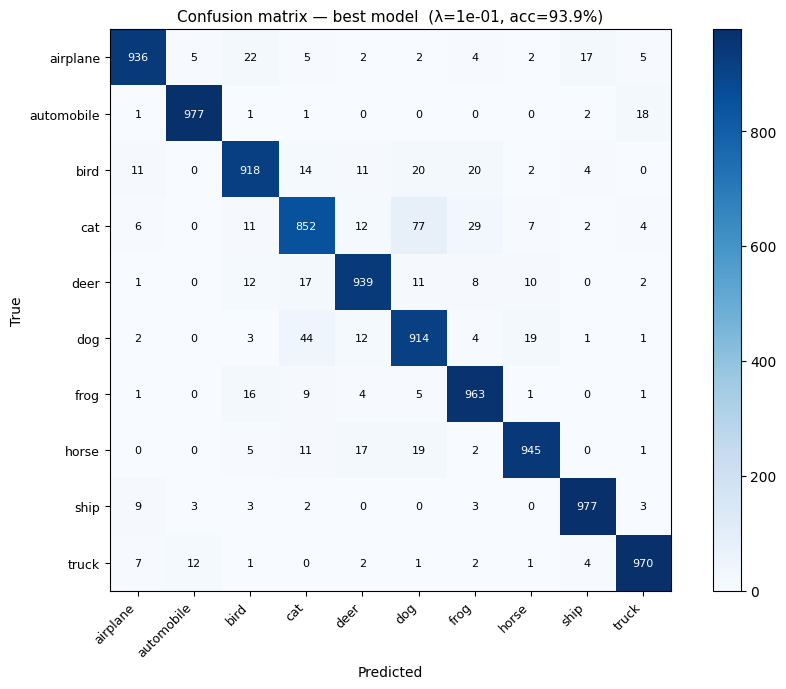

In [31]:
import itertools

# Results table
print("\n" + "="*62)
print(f"  {'Lambda':>8}  {'Best Acc':>10}  {'Sparsity':>10}  "
      f"{'fc1':>8}  {'fc2':>8}")
print("="*62)
for lam in LAMBDA_VALUES:
    r  = all_results[lam]
    ls = r["layer_sparsity"]
    print(f"  {lam:>8.1e}  {r['best_acc']:>9.2f}%  "
          f"{r['final_sparsity']:>9.1f}%  "
          f"{ls.get('fc1','—'):>8}  {ls.get('fc2','—'):>8}")
print("="*62)

# Confusion matrix for best model
best_lam   = max(all_results, key=lambda k: all_results[k]["best_acc"])
model_best = SEResNetPrunable(gate_type="sigmoid").to(device)
model_best.load_state_dict(
    torch.load(f"{CKPT_DIR}/best_lam{best_lam:.0e}.pt", map_location=device)
)
model_best.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        preds = model_best(images.to(device)).argmax(1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

conf = np.zeros((10, 10), dtype=int)
for t, p in zip(all_labels, all_preds):
    conf[t][p] += 1

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(conf, cmap="Blues")
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xticklabels(CLASSES, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(CLASSES, fontsize=9)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"Confusion matrix — best model  "
             f"(λ={best_lam:.0e}, acc={all_results[best_lam]['best_acc']:.1f}%)",
             fontsize=11)
for i, j in itertools.product(range(10), range(10)):
    ax.text(j, i, conf[i,j], ha="center", va="center", fontsize=8,
            color="white" if conf[i,j] > conf.max()*0.6 else "black")
plt.colorbar(im, fraction=0.046)
plt.tight_layout(); plt.show()

In [35]:
import json

for target_lam in LAMBDA_VALUES:
    r = all_results[target_lam]
    
    # Save full checkpoint (model + optimizer state + history)
    checkpoint = {
        "model_state_dict"  : torch.load(f"{CKPT_DIR}/best_lam{target_lam:.0e}.pt",
                                          map_location="cpu"),
        "lambda"            : target_lam,
        "best_accuracy"     : r["best_acc"],
        "history"           : r["history"],
        "config": {
            "epochs"        : EPOCHS,
            "gate_type"     : "sigmoid",
            "cifar_mean"    : CIFAR_MEAN,
            "cifar_std"     : CIFAR_STD,
            "classes"       : CLASSES,
        }
    }
    
    save_path = f"{CKPT_DIR}/checkpoint_lam{target_lam:.0e}.pt"
    torch.save(checkpoint, save_path)
    print(f"Saved → {save_path}")

# Save results summary as JSON (easy to read later)
summary = {
    str(lam): {
        "best_accuracy"  : all_results[lam]["best_acc"]
    }
    for lam in LAMBDA_VALUES
}
with open(f"{CKPT_DIR}/results_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(f"\nResults summary saved → {CKPT_DIR}/results_summary.json")
print(json.dumps(summary, indent=2))

Saved → /kaggle/working/checkpoint_lam1e-01.pt
Saved → /kaggle/working/checkpoint_lam1e+00.pt
Saved → /kaggle/working/checkpoint_lam5e+00.pt

Results summary saved → /kaggle/working/results_summary.json
{
  "0.1": {
    "best_accuracy": 93.91
  },
  "1.0": {
    "best_accuracy": 93.64
  },
  "5.0": {
    "best_accuracy": 93.38
  }
}
